In [15]:
import pandas as pd
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.config as config
import src.profile_model_registry as profile_model_registry
import src.profile_tracker as profile_tracker
import src.profile_trainer as profile_trainer

importlib.reload(config)
importlib.reload(profile_model_registry)
importlib.reload(profile_tracker)
importlib.reload(profile_trainer)

from src.profile_trainer import run_profile_training_experiment

print(profile_model_registry.get_profile_dense_models().keys())
print(profile_model_registry.get_profile_nan_friendly_models().keys())

dict_keys(['ridge', 'random_forest', 'xgboost', 'catboost'])
dict_keys(['hist_gbr', 'xgboost'])


    "BU_TotActPwr_Academy",
    "BA_TotActPwr_BESS_AC_Panel1",
    "BA_TotActPwr_BESS_AC_Panel2",
    "BU_TotActPwr_Tech_Room",
    "BU_TotActPwr_SDB_EL_Substation",

In [16]:
path = r"C:\Data_analysis\Thesis\Data\03_Training\Imputed_data\15_min\df_BU_TotActPwr_Academy.parquet"
df_imputed = pd.read_parquet(path)

In [17]:
df_imputed.head()

,BU_TotActPwr_Academy,BA_Soc,PV_WS_AirTemp,PV_WS_Radiation,dayofweek,is_weekend,hour,sin_tod,cos_tod,sin_dow,...,BU_TotActPwr_Academy_roll_std_96,BU_TotActPwr_Academy_trend_4_8,BU_TotActPwr_Academy_trend_4_12,BU_TotActPwr_Academy_trend_4_96,BU_TotActPwr_Academy_trend_96_192,BU_TotActPwr_Academy_yesterday_mean,BU_TotActPwr_Academy_yesterday_max,BU_TotActPwr_Academy_yesterday_midday_max,BU_TotActPwr_Academy_yesterday_peak_time_step,BU_TotActPwr_Academy_lastweek_same_day_peak
Time,,,,,,,,,,,,,,,,,,,,,
2025-10-18 00:00:00,3.76667,81.00000,143.00000,-1.73333,5,1,0,0.000000,1.000000,-0.974928,...,3.065762,0.02766,-0.00434,-0.47967,0.50267,6.270889,12.751,12.751,52.0,NaN
2025-10-18 00:15:00,4.80533,80.66667,143.00000,-1.50000,5,1,0,0.065403,0.997859,-0.974928,...,3.069365,-0.23400,-0.59000,-0.17934,0.30300,6.270889,12.751,12.751,52.0,NaN
2025-10-18 00:30:00,4.85767,80.20000,142.66667,-1.73333,5,1,0,0.130526,0.991445,-0.974928,...,3.064911,-0.29267,-0.25500,-0.19067,-0.01000,6.270889,12.751,12.751,52.0,NaN
2025-10-18 00:45:00,4.11967,79.83333,141.66667,-2.16667,5,1,0,0.195090,0.980785,-0.974928,...,3.058301,-0.28900,-0.68867,-0.03000,-0.14967,6.270889,12.751,12.751,52.0,NaN
2025-10-18 01:00:00,3.62533,79.40000,140.33333,-3.13333,5,1,1,0.258819,0.965926,-0.974928,...,3.056022,0.01734,0.04500,-0.94333,0.87267,6.270889,12.751,12.751,52.0,NaN


In [24]:
from src.peak_specialist import run_peak_specialist_experiment

target_col = "BU_TotActPwr_Academy"
feature_cols = [c for c in df_imputed.columns if c != target_col]

peak_results, peak_horizon, peak_predictions, peak_model = run_peak_specialist_experiment(
    df=df_imputed,
    target_col=target_col,
    feature_cols=feature_cols,
    dataset_name="peak_specialist_10_18",
    output_dir=r"C:\Data_analysis\Thesis\outputs\peaks",
    peak_start_hour=10,
    peak_end_hour=18,
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    train_ratio=0.80,
    val_ratio=0.10,
    test_ratio=0.10,
    drop_feature_nan=False,
)

peak_results

,timestamp,task_type,dataset_name,target,model_name,peak_start_hour,peak_end_hour,peak_horizon_start,peak_horizon_end,n_peak_horizons,...,val_MAPE,val_sMAPE,val_R2,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_R2,prediction_path,horizon_metrics_path
0,2026-04-28 15:33:55,peak_specialist_profile_forecasting,peak_specialist_10_18,BU_TotActPwr_Academy,peak_specialist_xgboost,10,18,41,72,32,...,29.390869,25.984467,0.486431,4.449074,5.971668,23.769628,25.948299,0.419378,C:\Data_analysis\Thesis\outputs\peaks\predicti...,C:\Data_analysis\Thesis\outputs\peaks\metrics\...


In [22]:
peak_horizon

,horizon_step,MAE,RMSE,MAPE,sMAPE,R2
0,1,5.886786,7.017019,27.583793,31.173197,0.120355
1,2,5.200360,6.523046,24.482748,26.061615,0.277547
2,3,4.816805,6.188803,23.115424,24.501479,0.191286
3,4,5.057255,6.746864,21.820969,24.759555,0.086669
4,5,4.725054,5.743280,24.400988,25.096155,0.266991
5,6,6.805102,7.933832,31.383845,35.190101,-0.137439
6,7,6.982541,8.891356,30.452580,34.717610,-0.197211
7,8,5.758779,7.601902,23.025896,27.359713,-0.171982
8,9,5.743260,7.285502,23.182501,27.779299,-0.396443
9,10,6.906765,8.023636,33.575892,37.148368,-0.310842


In [25]:
print(peak_predictions.shape)
print(peak_predictions.columns[:10])
print(peak_predictions.index[:5])

(12, 64)
Index(['y_tplus_041_true', 'y_tplus_042_true', 'y_tplus_043_true',
       'y_tplus_044_true', 'y_tplus_045_true', 'y_tplus_046_true',
       'y_tplus_047_true', 'y_tplus_048_true', 'y_tplus_049_true',
       'y_tplus_050_true'],
      dtype='str')
DatetimeIndex(['2026-01-27 23:45:00', '2026-01-28 23:45:00',
               '2026-01-29 23:45:00', '2026-01-30 23:45:00',
               '2026-01-31 23:45:00'],
              dtype='datetime64[us]', name='Time', freq=None)


In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_peak_prediction_day(peak_predictions, day_idx=0, peak_start_hour=10, freq_minutes=15):
    """
    Plot actual vs predicted peak-window profile for one test day.

    peak_predictions:
        DataFrame returned from run_peak_specialist_experiment()
        columns should contain *_true and *_pred
    day_idx:
        which test day to plot, e.g. 0, 1, 2...
    """

    row = peak_predictions.iloc[day_idx]

    true_cols = [c for c in peak_predictions.columns if c.endswith("_true")]
    pred_cols = [c for c in peak_predictions.columns if c.endswith("_pred")]

    true_cols = sorted(true_cols)
    pred_cols = sorted(pred_cols)

    y_true = row[true_cols].values.astype(float)
    y_pred = row[pred_cols].values.astype(float)

    n_steps = len(y_true)

    times = pd.date_range(
        start=f"{peak_start_hour:02d}:00",
        periods=n_steps,
        freq=f"{freq_minutes}min"
    ).strftime("%H:%M")

    plt.figure(figsize=(14, 5))
    plt.plot(times, y_true, marker="o", label="Actual")
    plt.plot(times, y_pred, marker="o", label="Predicted")

    plt.title(f"Peak-specialist prediction | Test day index: {day_idx}")
    plt.xlabel("Time of day")
    plt.ylabel("Load")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

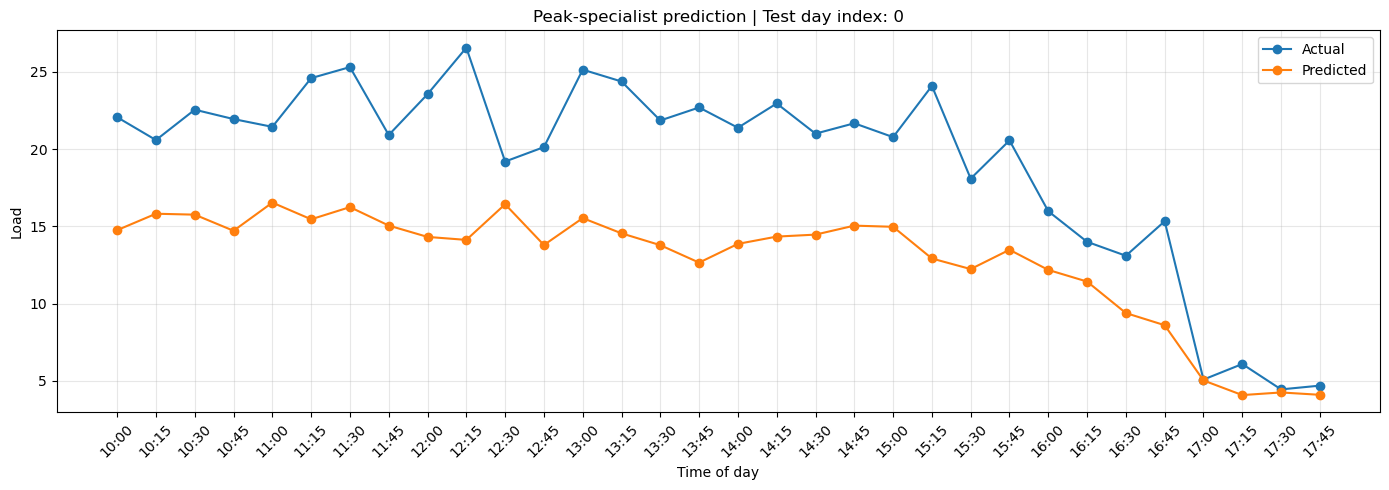

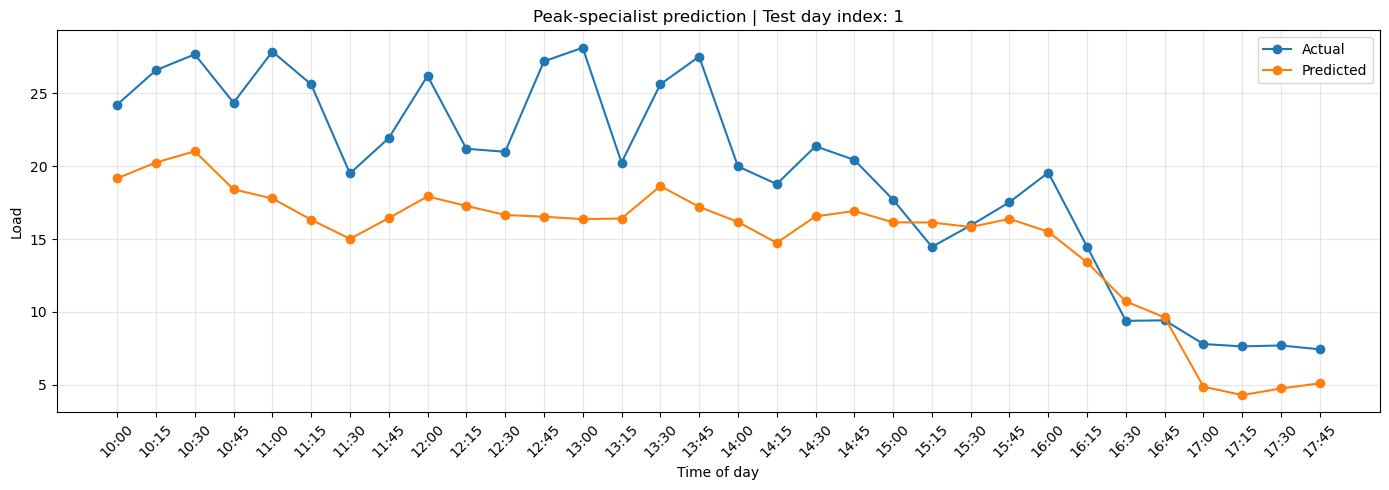

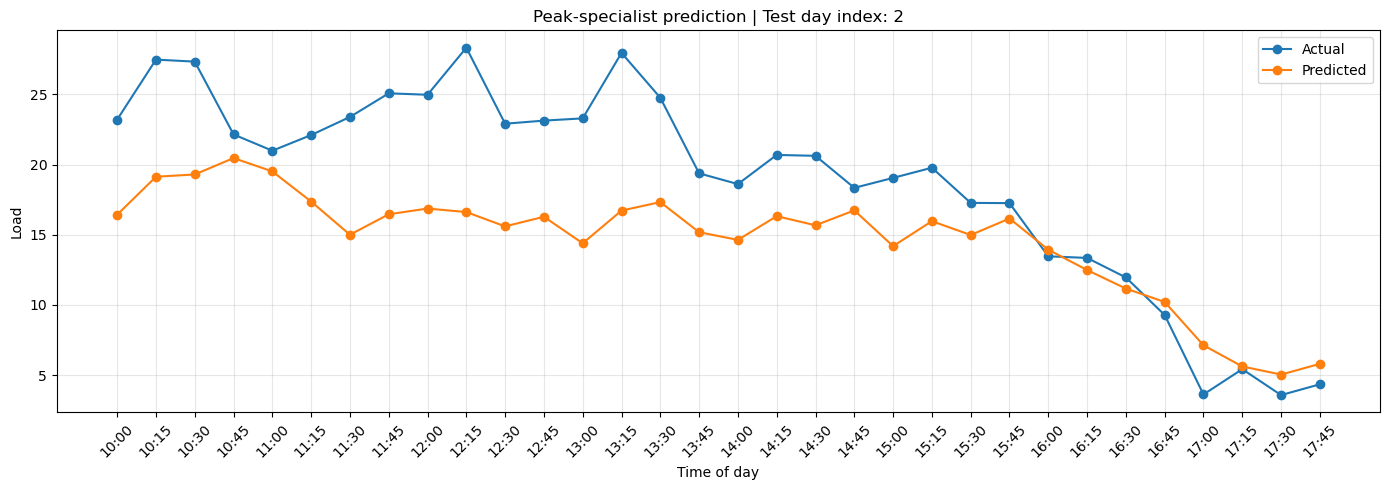

In [27]:
plot_peak_prediction_day(peak_predictions, day_idx=0)
plot_peak_prediction_day(peak_predictions, day_idx=1)
plot_peak_prediction_day(peak_predictions, day_idx=2)

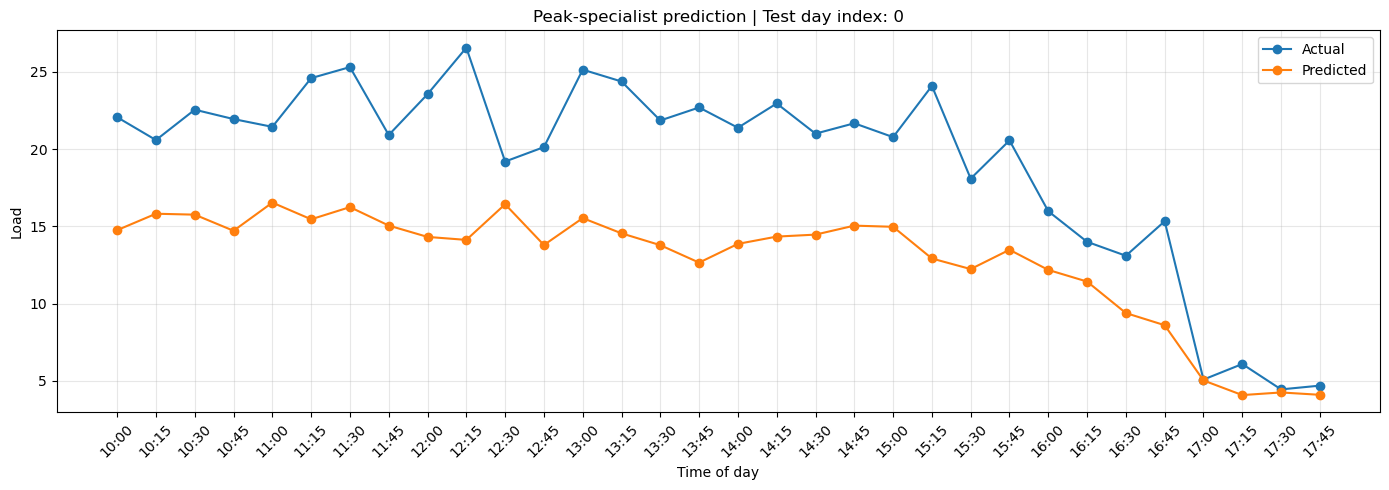

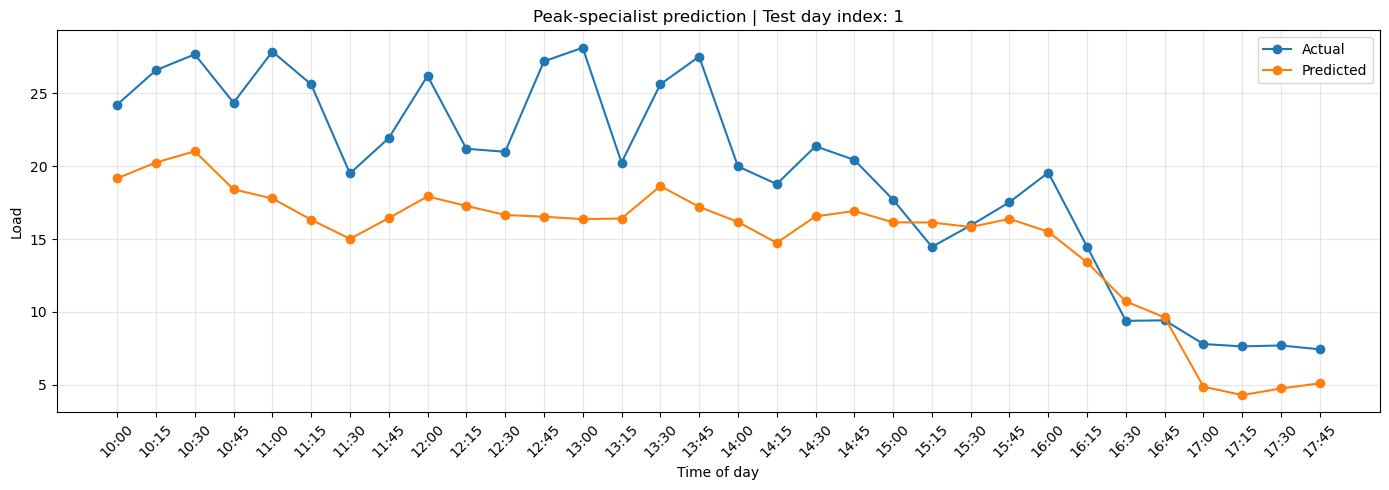

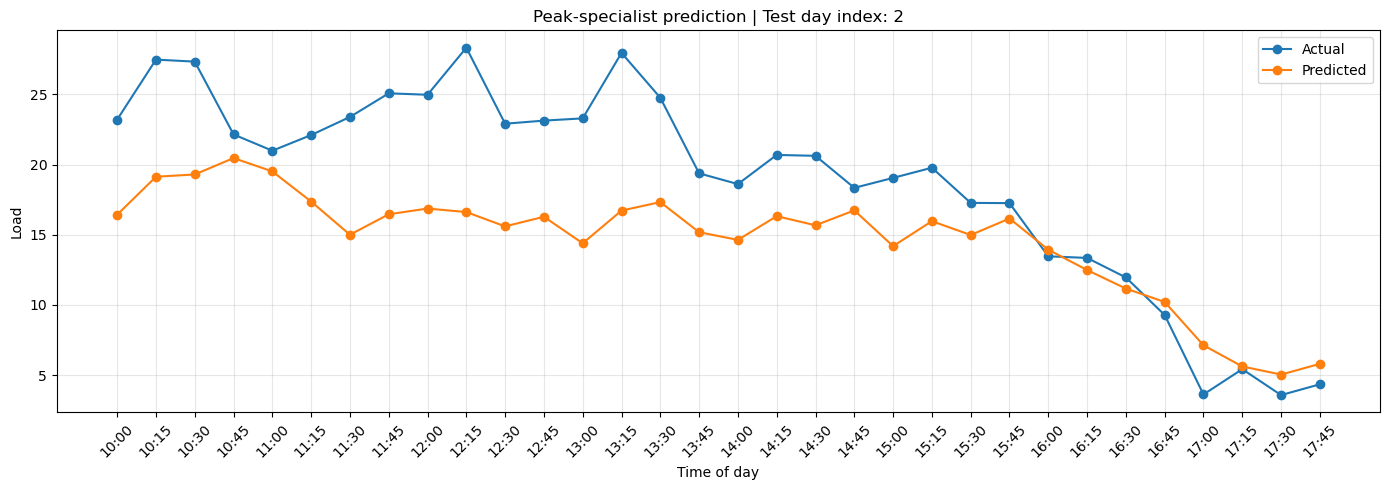

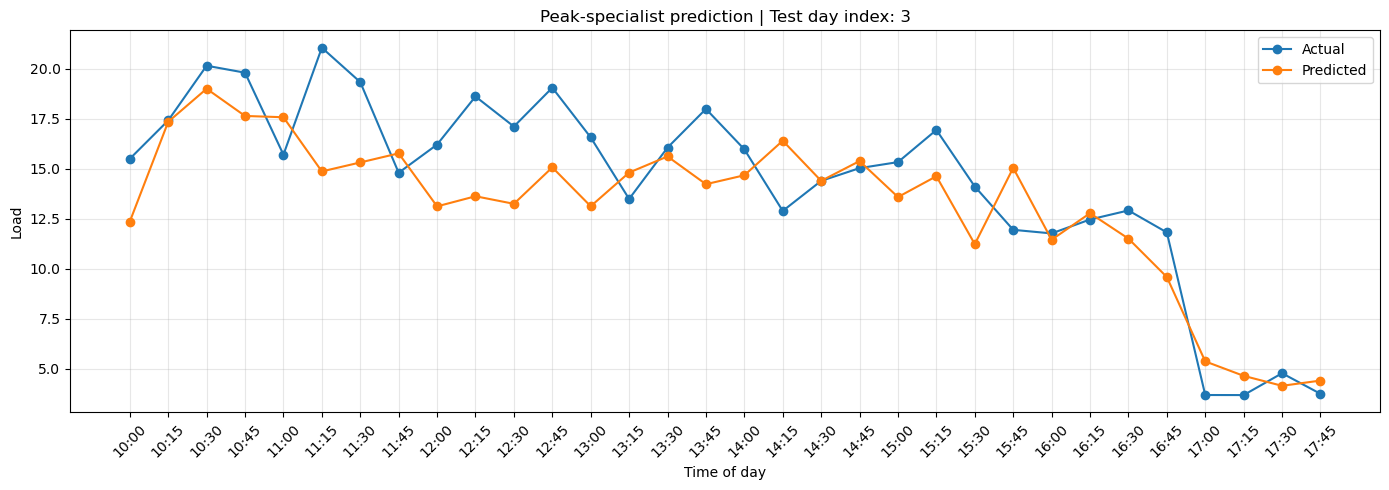

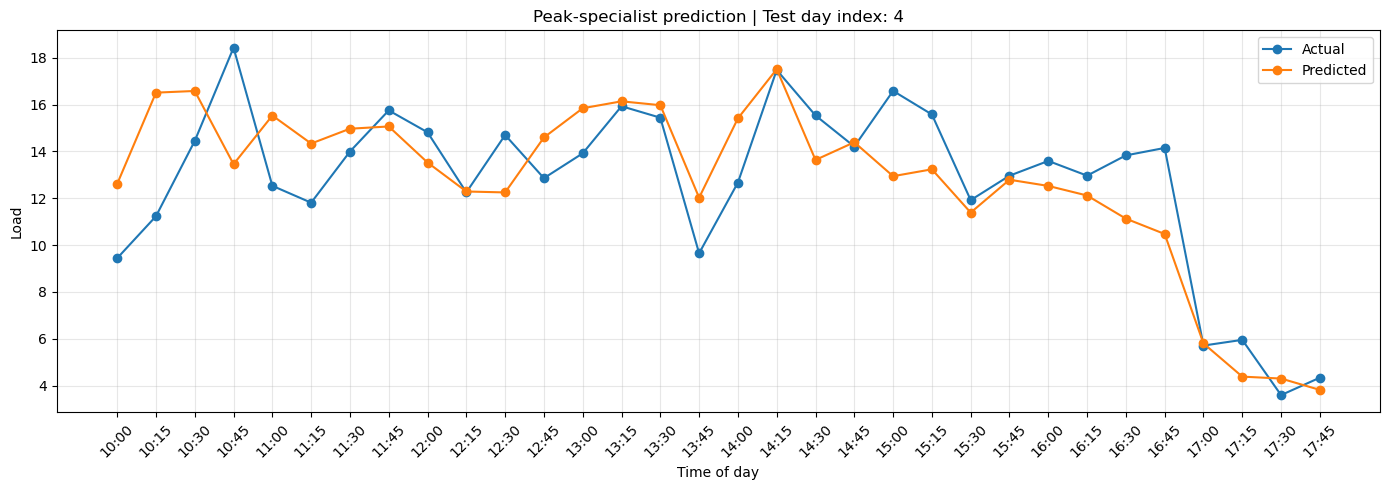

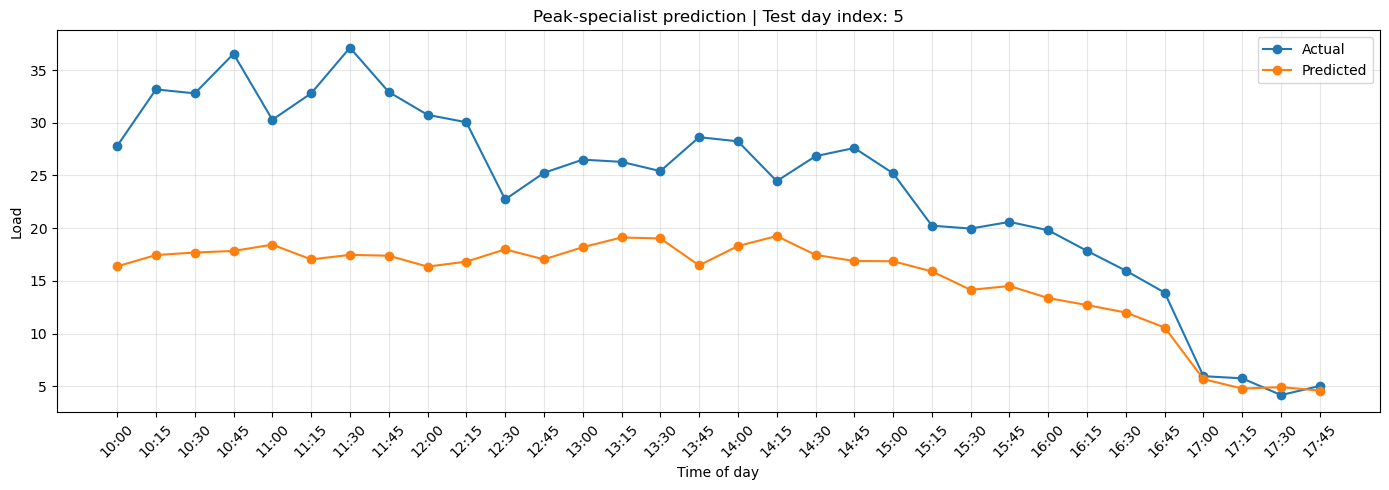

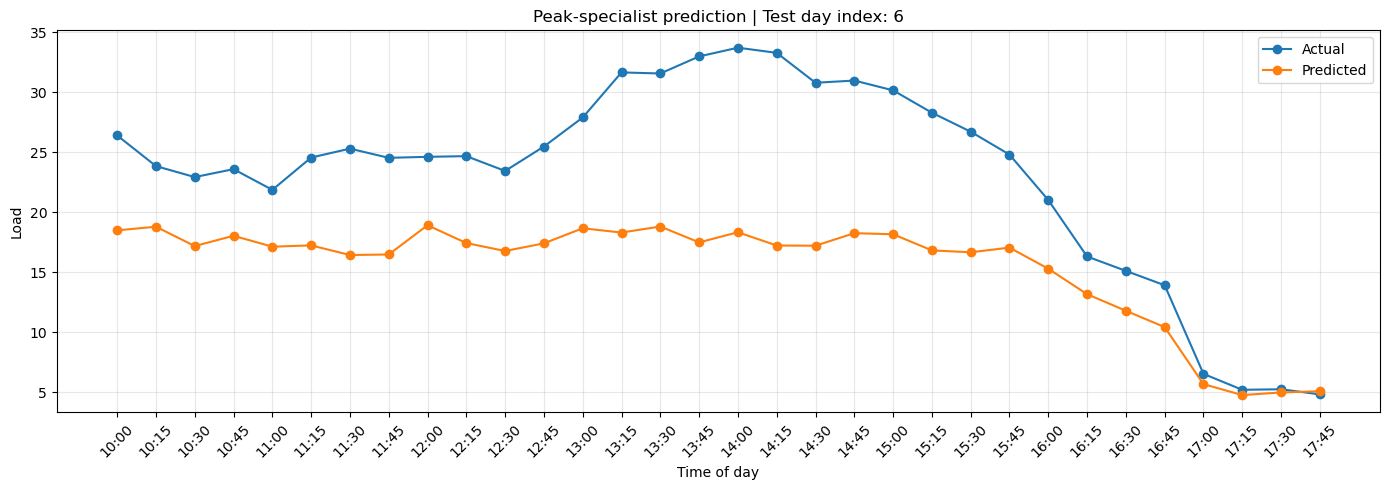

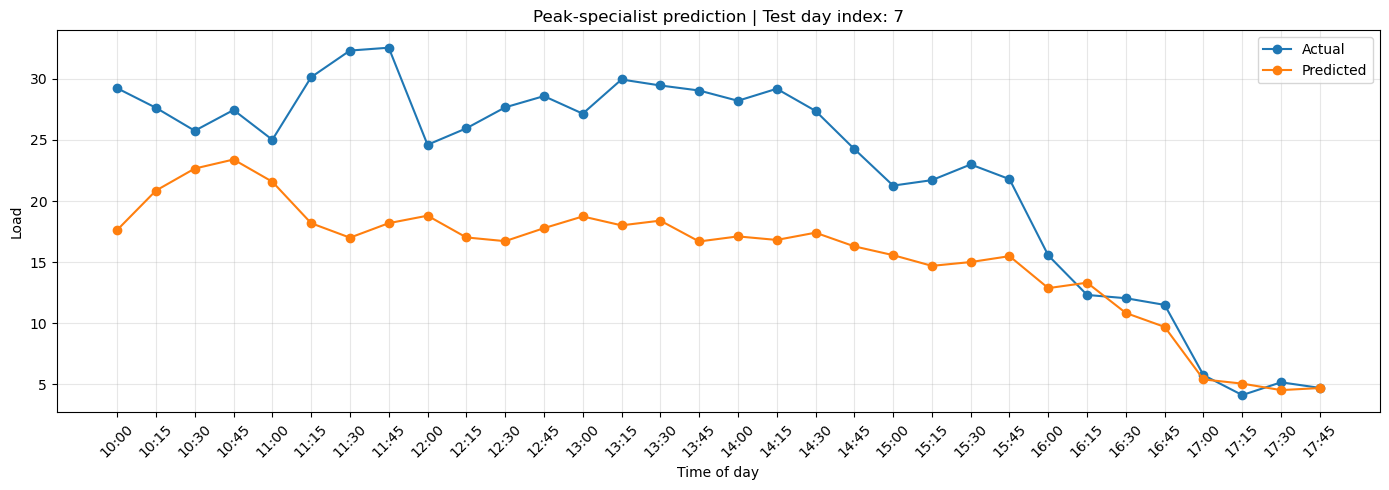

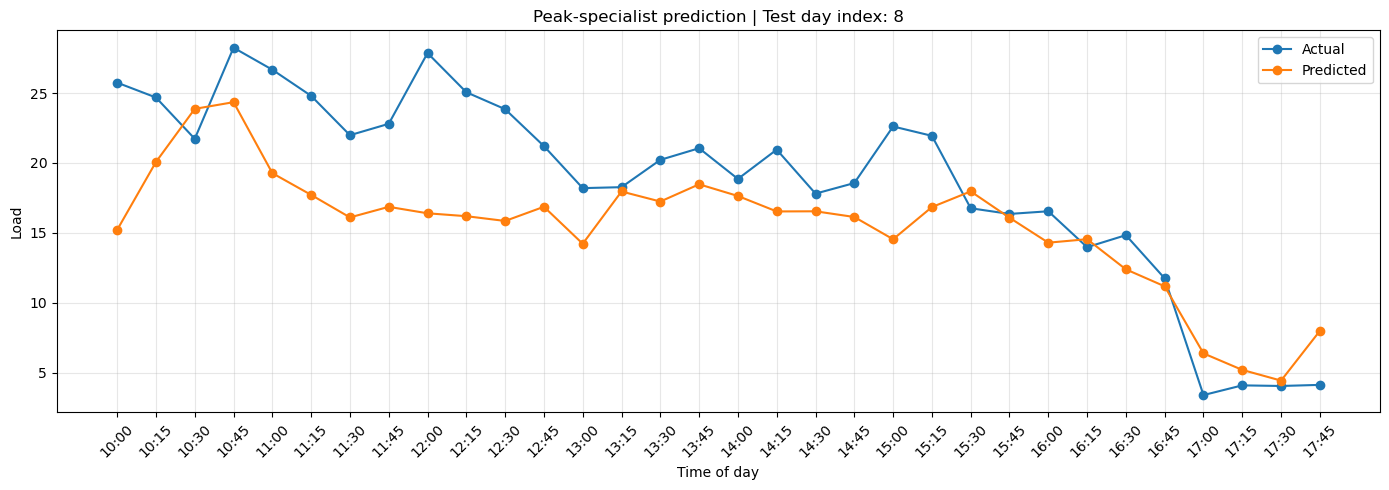

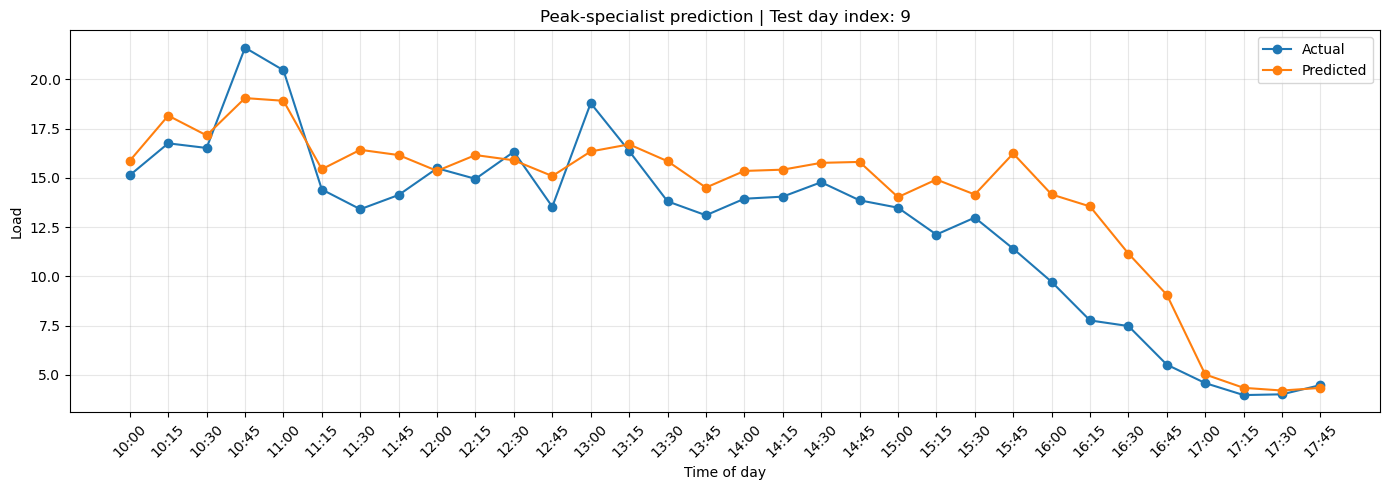

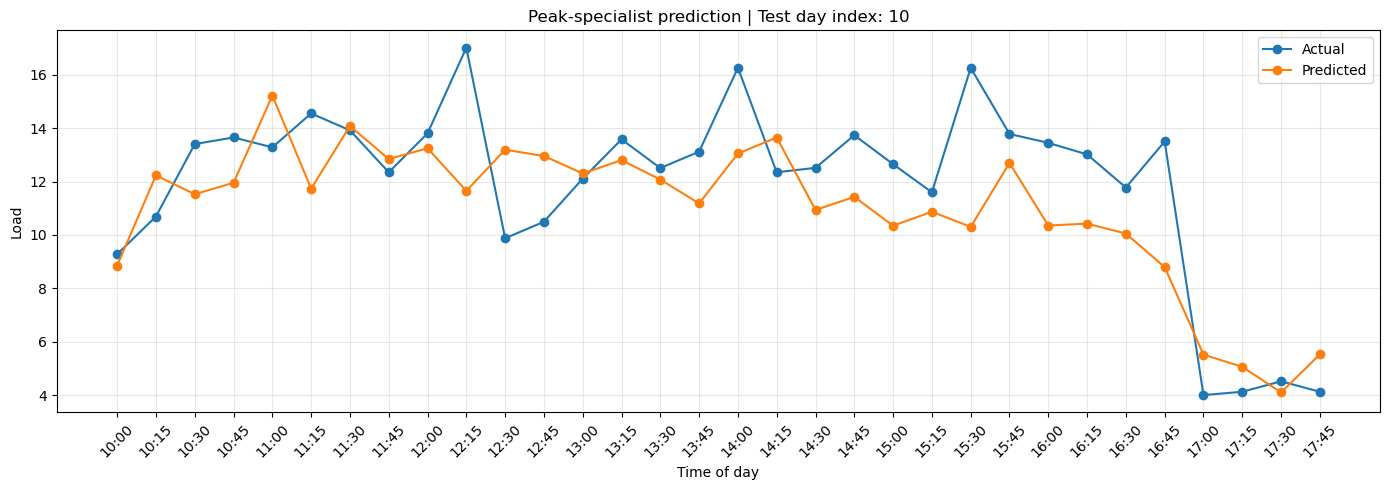

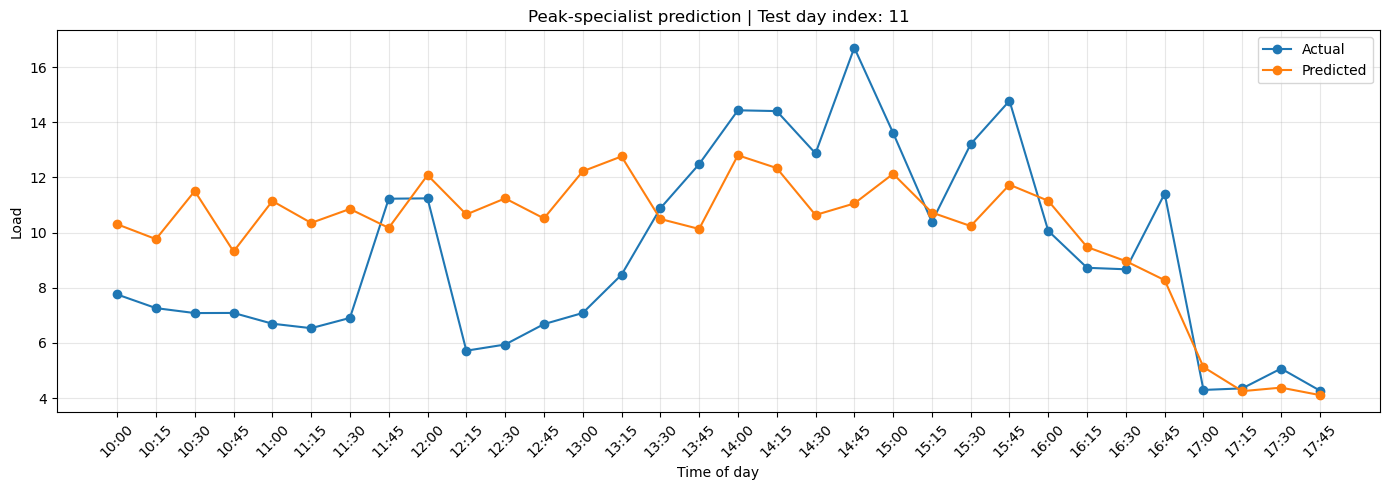

In [28]:
for i in range(len(peak_predictions)):
    plot_peak_prediction_day(peak_predictions, day_idx=i)

In [29]:
def plot_peak_horizon_metrics(peak_horizon, peak_start_hour=10, freq_minutes=15):
    df = peak_horizon.copy()

    times = pd.date_range(
        start=f"{peak_start_hour:02d}:00",
        periods=len(df),
        freq=f"{freq_minutes}min"
    ).strftime("%H:%M")

    df["time_of_day"] = times

    plt.figure(figsize=(14, 5))
    plt.plot(df["time_of_day"], df["MAE"], marker="o", label="MAE")
    plt.plot(df["time_of_day"], df["RMSE"], marker="o", label="RMSE")

    plt.title("Peak-specialist horizon-wise MAE/RMSE")
    plt.xlabel("Time of day")
    plt.ylabel("Error")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(df["time_of_day"], df["MAPE"], marker="o", label="MAPE")
    plt.plot(df["time_of_day"], df["sMAPE"], marker="o", label="sMAPE")

    plt.title("Peak-specialist horizon-wise MAPE/sMAPE")
    plt.xlabel("Time of day")
    plt.ylabel("Percentage error")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df

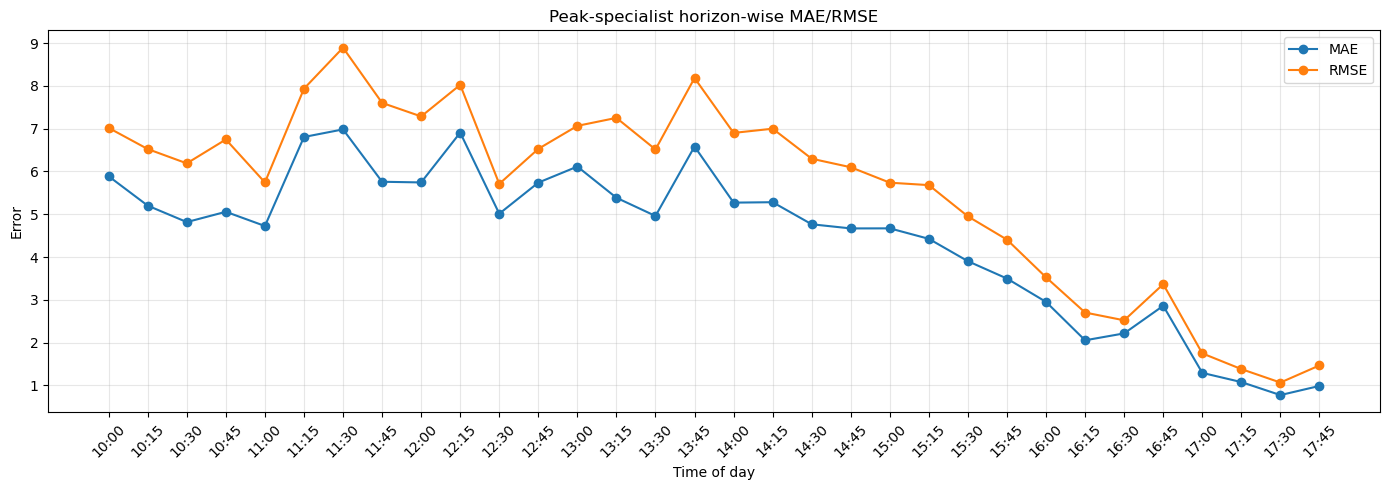

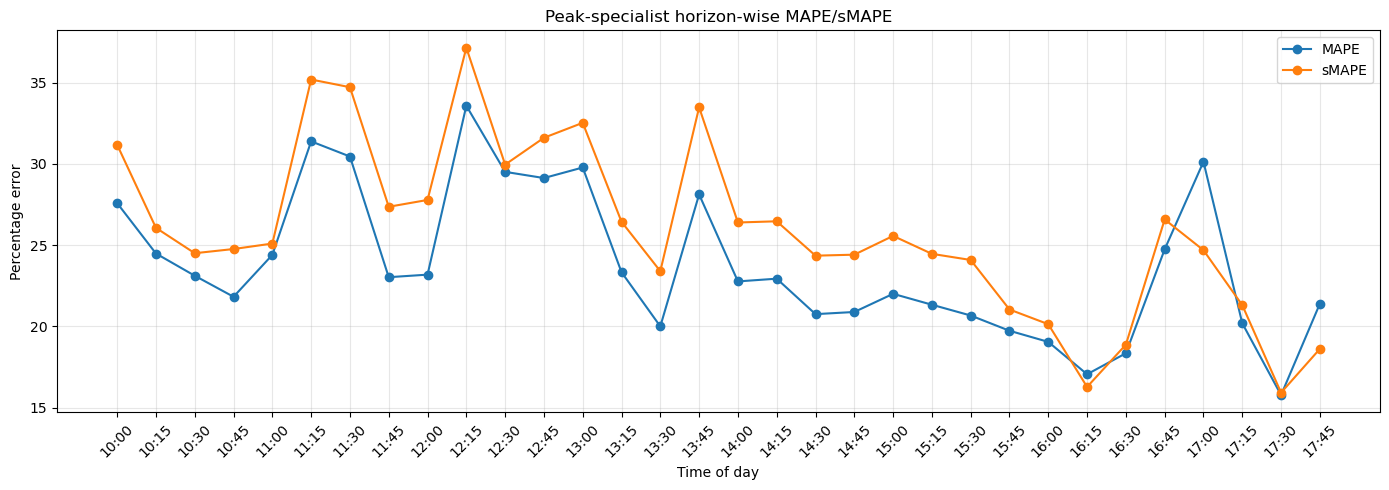

,horizon_step,MAE,RMSE,MAPE,sMAPE,R2,time_of_day
0,1,5.886786,7.017019,27.583793,31.173197,0.120355,10:00
1,2,5.200360,6.523046,24.482748,26.061615,0.277547,10:15
2,3,4.816805,6.188803,23.115424,24.501479,0.191286,10:30
3,4,5.057255,6.746864,21.820969,24.759555,0.086669,10:45
4,5,4.725054,5.743280,24.400988,25.096155,0.266991,11:00
5,6,6.805102,7.933832,31.383845,35.190101,-0.137439,11:15
6,7,6.982541,8.891356,30.452580,34.717610,-0.197211,11:30
7,8,5.758779,7.601902,23.025896,27.359713,-0.171982,11:45
8,9,5.743260,7.285502,23.182501,27.779299,-0.396443,12:00
9,10,6.906765,8.023636,33.575892,37.148368,-0.310842,12:15


In [30]:
peak_horizon_with_time = plot_peak_horizon_metrics(peak_horizon)
peak_horizon_with_time

In [31]:
def calculate_peak_bias_summary(peak_predictions):
    true_cols = sorted([c for c in peak_predictions.columns if c.endswith("_true")])
    pred_cols = sorted([c for c in peak_predictions.columns if c.endswith("_pred")])

    y_true = peak_predictions[true_cols].values
    y_pred = peak_predictions[pred_cols].values

    error = y_pred - y_true

    summary = {
        "mean_bias_pred_minus_actual": np.mean(error),
        "median_bias_pred_minus_actual": np.median(error),
        "mean_absolute_error": np.mean(np.abs(error)),
        "actual_peak_mean": np.mean(y_true),
        "predicted_peak_mean": np.mean(y_pred),
        "actual_peak_max": np.max(y_true),
        "predicted_peak_max": np.max(y_pred),
        "peak_max_error": np.max(y_pred) - np.max(y_true),
    }

    return pd.DataFrame([summary])

In [23]:
peak_predictions.head()

,y_tplus_041_true,y_tplus_042_true,y_tplus_043_true,y_tplus_044_true,y_tplus_045_true,y_tplus_046_true,y_tplus_047_true,y_tplus_048_true,y_tplus_049_true,y_tplus_050_true,...,y_tplus_063_pred,y_tplus_064_pred,y_tplus_065_pred,y_tplus_066_pred,y_tplus_067_pred,y_tplus_068_pred,y_tplus_069_pred,y_tplus_070_pred,y_tplus_071_pred,y_tplus_072_pred
Time,,,,,,,,,,,,,,,,,,,,,
2026-01-27 23:45:00,22.06867,20.59067,22.55633,21.94967,21.44600,24.59900,25.31300,20.91800,23.55867,26.56800,...,12.241054,13.490274,12.186805,11.432940,9.394215,8.608795,5.034287,4.086607,4.256546,4.104136
2026-01-28 23:45:00,24.23000,26.59800,27.68567,24.36733,27.87533,25.62500,19.50700,21.93600,26.20700,21.20467,...,15.828792,16.391333,15.505688,13.403956,10.721758,9.621326,4.867519,4.292678,4.747306,5.099778
2026-01-29 23:45:00,23.20300,27.47767,27.33467,22.14533,20.98600,22.10233,23.39133,25.07633,24.97300,28.32667,...,14.979509,16.153944,13.932477,12.483212,11.160751,10.207502,7.118735,5.611795,5.031930,5.798633
2026-01-30 23:45:00,15.50133,17.42033,20.15767,19.80867,15.70767,21.05900,19.33900,14.80300,16.21233,18.61833,...,11.232692,15.047782,11.452586,12.778689,11.508409,9.586988,5.365940,4.643238,4.144745,4.406681
2026-01-31 23:45:00,9.43600,11.22867,14.44667,18.42733,12.52867,11.80800,13.99300,15.74933,14.81533,12.24867,...,11.385666,12.788898,12.523889,12.114789,11.126963,10.471282,5.798078,4.380136,4.297392,3.813550


In [32]:
bias_summary = calculate_peak_bias_summary(peak_predictions)
bias_summary

,mean_bias_pred_minus_actual,median_bias_pred_minus_actual,mean_absolute_error,actual_peak_mean,predicted_peak_mean,actual_peak_max,predicted_peak_max,peak_max_error
0,-3.487977,-2.58769,4.449074,17.233652,13.745674,37.11933,24.349049,-12.770281


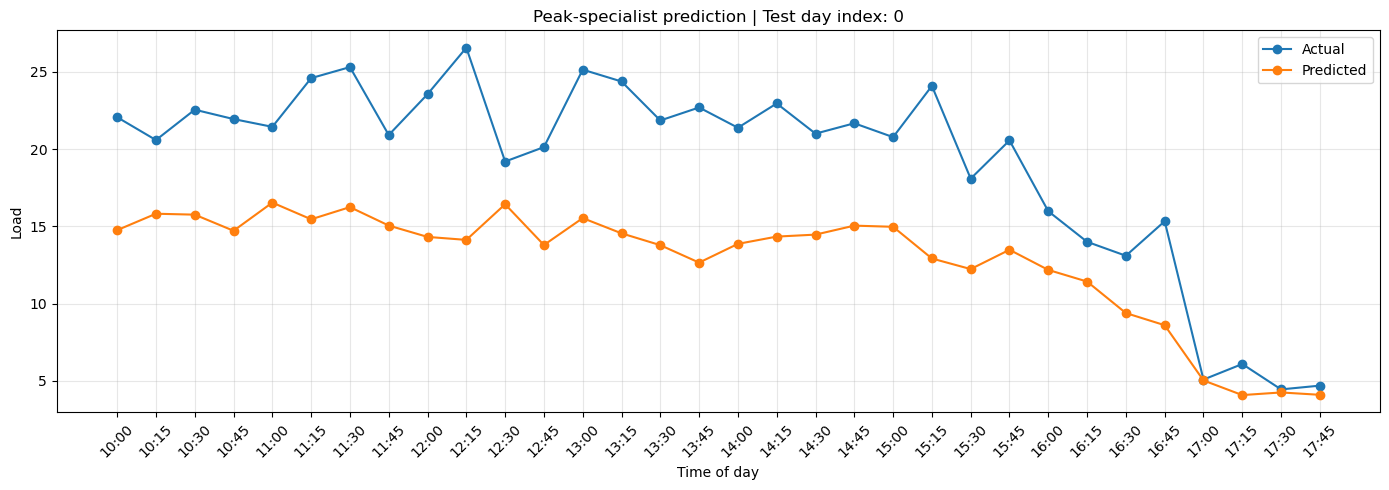

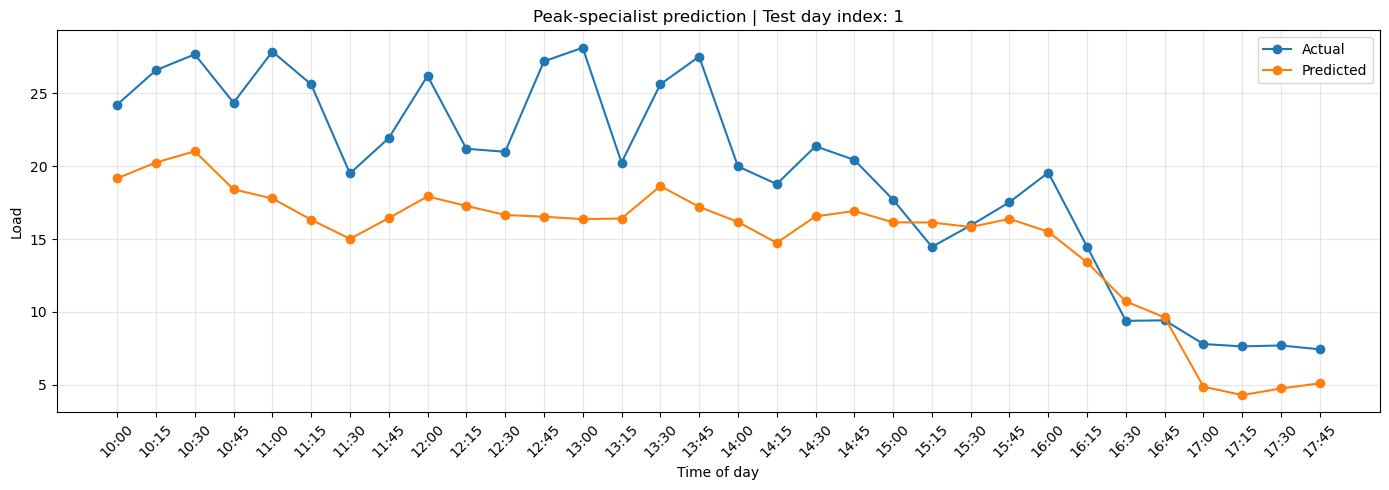

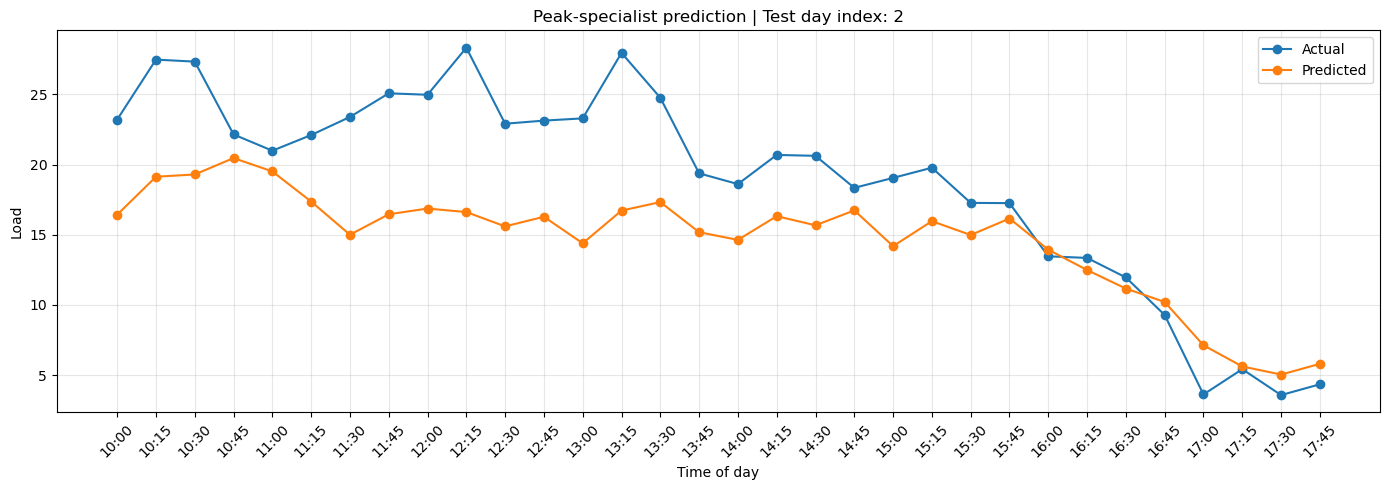

NameError: name 'plot_peak_predictions_continuous' is not defined

In [33]:
plot_peak_prediction_day(peak_predictions, day_idx=0)
plot_peak_prediction_day(peak_predictions, day_idx=1)
plot_peak_prediction_day(peak_predictions, day_idx=2)

plot_peak_predictions_continuous(peak_predictions)

plot_peak_residuals(peak_predictions)

peak_horizon_with_time = plot_peak_horizon_metrics(peak_horizon)

plot_peak_scatter(peak_predictions)

calculate_peak_bias_summary(peak_predictions)

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

target_col = "BU_TotActPwr_Academy"

def split_by_ratio(df, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15):
    df = df.sort_index().copy()
    n = len(df)

    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    return train_df, val_df, test_df

train_df, val_df, test_df = split_by_ratio(
    df_imputed,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
)

def load_distribution_summary(train_df, val_df, test_df, target_col):
    rows = []

    for name, d in [
        ("train", train_df),
        ("val", val_df),
        ("test", test_df),
    ]:
        s = d[target_col].dropna()

        rows.append({
            "split": name,
            "start": d.index.min(),
            "end": d.index.max(),
            "n_samples": len(s),
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "min": s.min(),
            "q10": s.quantile(0.10),
            "q25": s.quantile(0.25),
            "q75": s.quantile(0.75),
            "q90": s.quantile(0.90),
            "q95": s.quantile(0.95),
            "max": s.max(),
        })

    return pd.DataFrame(rows)

split_summary = load_distribution_summary(train_df, val_df, test_df, target_col)
split_summary

,split,start,end,n_samples,mean,median,std,min,q10,q25,q75,q90,q95,max
0,train,2025-10-18 00:00:00,2026-01-05 18:45:00,7660,7.315349,5.118835,4.795385,2.02667,2.668636,3.732000,10.575753,14.576270,17.085034,30.31700
1,val,2026-01-05 19:00:00,2026-01-22 21:00:00,1641,8.176350,5.225000,5.936862,2.09867,3.058000,3.907670,12.128330,17.648330,19.805000,51.22767
2,test,2026-01-22 21:15:00,2026-02-08 23:45:00,1643,9.087651,5.058000,7.320209,2.18667,3.129398,3.895335,12.986500,21.353066,24.814500,37.11933


In [40]:
def filter_time_window(df, start_hour=10, end_hour=18):
    return df[(df.index.hour >= start_hour) & (df.index.hour < end_hour)].copy()

train_peak = filter_time_window(train_df, 10, 18)
val_peak = filter_time_window(val_df, 10, 18)
test_peak = filter_time_window(test_df, 10, 18)

peak_split_summary = load_distribution_summary(
    train_peak,
    val_peak,
    test_peak,
    target_col,
)

peak_split_summary

,split,start,end,n_samples,mean,median,std,min,q10,q25,q75,q90,q95,max
0,train,2025-10-18 10:00:00,2026-01-05 17:45:00,2560,11.415096,11.357000,4.695556,2.49467,5.007770,7.783170,14.663000,17.647836,19.412697,30.31700
1,val,2026-01-06 10:00:00,2026-01-22 17:45:00,544,12.913946,13.831335,6.546916,2.62500,4.524531,6.175998,17.580415,20.341030,22.386719,51.22767
2,test,2026-01-23 10:00:00,2026-02-08 17:45:00,544,15.594074,14.405665,7.634420,3.38500,5.300631,9.409917,21.219582,26.475068,28.324120,37.11933


In [42]:
def daily_load_summary(df, target_col, freq_minutes=15):
    s = df[target_col].dropna().copy()

    daily = pd.DataFrame({
        "daily_mean": s.resample("D").mean(),
        "daily_median": s.resample("D").median(),
        "daily_std": s.resample("D").std(),
        "daily_min": s.resample("D").min(),
        "daily_max": s.resample("D").max(),
        "daily_q90": s.resample("D").quantile(0.90),
        "daily_q95": s.resample("D").quantile(0.95),
    })

    # kWh estimate: kW * hours per sample
    daily["daily_energy_kwh"] = s.resample("D").sum() * (freq_minutes / 60)

    daily = daily.dropna(how="all")
    return daily

daily_summary = daily_load_summary(df_imputed, target_col, freq_minutes=15)
daily_summary.head()

,daily_mean,daily_median,daily_std,daily_min,daily_max,daily_q90,daily_q95,daily_energy_kwh
Time,,,,,,,,
2025-10-18,4.745212,4.526665,1.660309,2.37800,9.45067,7.147165,7.383415,113.885085
2025-10-19,4.114636,4.047835,1.111523,2.38500,7.20800,5.536835,6.280750,98.751253
2025-10-20,6.730572,6.218500,2.967090,2.30133,11.83967,10.546500,10.807498,161.533738
2025-10-21,7.011386,6.003170,2.481165,3.87800,12.54667,10.240830,11.377253,168.273253
2025-10-22,6.845056,5.116000,3.334419,2.80467,20.42600,11.277500,12.052085,164.281345


In [44]:
def weekly_load_summary(df, target_col, freq_minutes=15):
    s = df[target_col].dropna().copy()

    weekly = pd.DataFrame({
        "weekly_mean": s.resample("W-MON").mean(),
        "weekly_median": s.resample("W-MON").median(),
        "weekly_std": s.resample("W-MON").std(),
        "weekly_min": s.resample("W-MON").min(),
        "weekly_max": s.resample("W-MON").max(),
        "weekly_q90": s.resample("W-MON").quantile(0.90),
        "weekly_q95": s.resample("W-MON").quantile(0.95),
    })

    weekly["weekly_energy_kwh"] = s.resample("W-MON").sum() * (freq_minutes / 60)

    weekly = weekly.dropna(how="all")
    return weekly

weekly_summary = weekly_load_summary(df_imputed, target_col, freq_minutes=15)
weekly_summary

,weekly_mean,weekly_median,weekly_std,weekly_min,weekly_max,weekly_q90,weekly_q95,weekly_energy_kwh
Time,,,,,,,,
2025-10-20,5.196807,4.554165,2.341440,2.30133,11.83967,9.422901,10.294335,374.170075
2025-10-27,6.452791,5.182665,3.190577,2.08633,20.42600,11.440900,12.428148,1084.068808
2025-11-03,6.291436,5.102835,3.411113,2.18400,16.16400,11.531267,12.527830,1056.961233
2025-11-10,6.052391,4.257335,3.775900,2.04433,17.57000,11.959167,13.192300,1016.801665
2025-11-17,6.918405,4.909000,4.464869,2.02667,22.37533,13.025967,16.091800,1162.291974
2025-11-24,8.842659,6.747000,5.125032,2.09533,24.94800,16.584603,18.485370,1485.566654
2025-12-01,7.138084,4.614000,5.058277,2.04000,22.67667,15.759370,17.347283,1199.198125
2025-12-08,8.874748,5.829000,6.329199,2.15767,30.31700,18.718464,20.730048,1490.957668
2025-12-15,8.129191,5.007330,5.447929,2.29133,26.92433,15.818570,17.660683,1365.704100


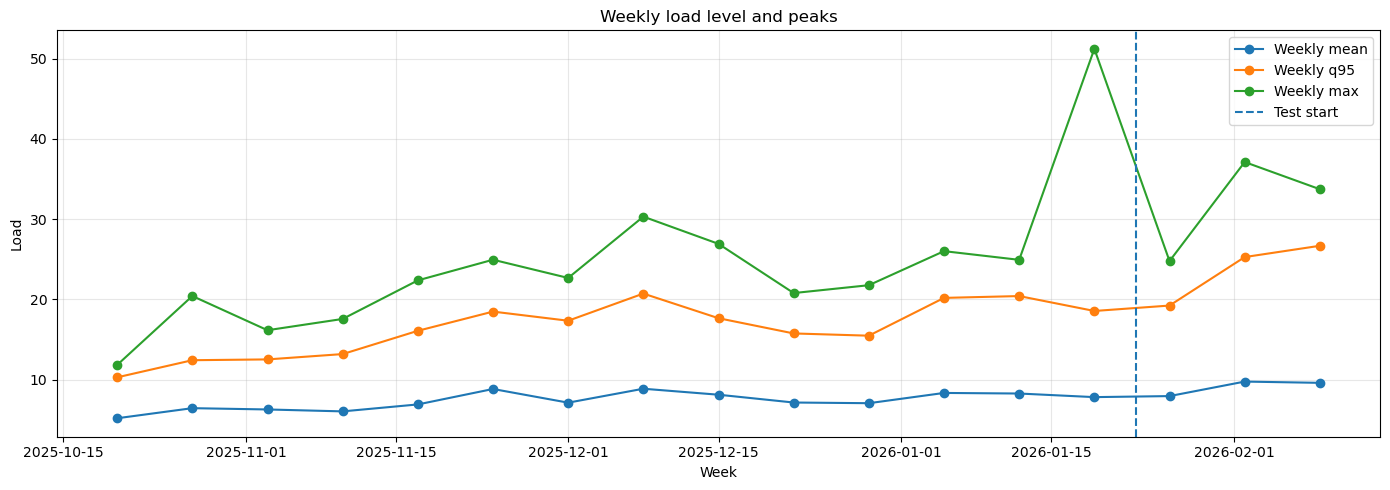

In [45]:
plt.figure(figsize=(14, 5))
plt.plot(weekly_summary.index, weekly_summary["weekly_mean"], marker="o", label="Weekly mean")
plt.plot(weekly_summary.index, weekly_summary["weekly_q95"], marker="o", label="Weekly q95")
plt.plot(weekly_summary.index, weekly_summary["weekly_max"], marker="o", label="Weekly max")
plt.axvline(test_df.index.min(), linestyle="--", label="Test start")
plt.title("Weekly load level and peaks")
plt.xlabel("Week")
plt.ylabel("Load")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
def daily_peak_window_summary(df, target_col, start_hour=10, end_hour=18, freq_minutes=15):
    d = filter_time_window(df, start_hour, end_hour)
    s = d[target_col].dropna().copy()

    daily = pd.DataFrame({
        "peakwin_mean": s.resample("D").mean(),
        "peakwin_median": s.resample("D").median(),
        "peakwin_std": s.resample("D").std(),
        "peakwin_min": s.resample("D").min(),
        "peakwin_max": s.resample("D").max(),
        "peakwin_q90": s.resample("D").quantile(0.90),
        "peakwin_q95": s.resample("D").quantile(0.95),
    })

    daily["peakwin_energy_kwh"] = s.resample("D").sum() * (freq_minutes / 60)

    return daily.dropna(how="all")

daily_peak_summary = daily_peak_window_summary(
    df_imputed,
    target_col,
    start_hour=10,
    end_hour=18,
    freq_minutes=15,
)

daily_peak_summary.head()

,peakwin_mean,peakwin_median,peakwin_std,peakwin_min,peakwin_max,peakwin_q90,peakwin_q95,peakwin_energy_kwh
Time,,,,,,,,
2025-10-18,6.145126,5.836335,1.050239,4.72367,9.45067,7.251430,7.568583,49.161005
2025-10-19,5.158354,4.844165,0.984501,3.64400,7.20800,6.629800,6.995482,41.266835
2025-10-20,9.557228,9.931830,1.276374,6.99833,11.83967,10.794730,10.877002,76.457827
2025-10-21,9.413604,9.382670,1.288161,6.90500,11.85000,11.352403,11.506201,75.308830
2025-10-22,9.947751,9.773335,2.564723,4.87200,20.42600,11.970070,12.512030,79.582005


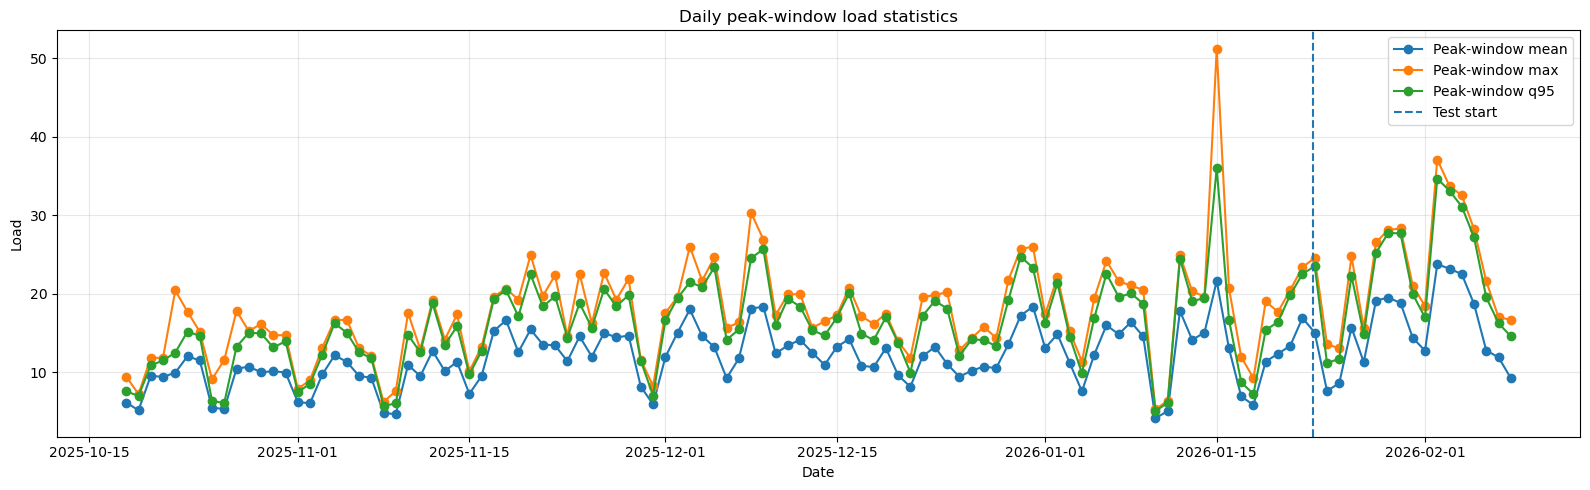

In [48]:
plt.figure(figsize=(16, 5))
plt.plot(daily_peak_summary.index, daily_peak_summary["peakwin_mean"], marker="o", label="Peak-window mean")
plt.plot(daily_peak_summary.index, daily_peak_summary["peakwin_max"], marker="o", label="Peak-window max")
plt.plot(daily_peak_summary.index, daily_peak_summary["peakwin_q95"], marker="o", label="Peak-window q95")
plt.axvline(test_df.index.min(), linestyle="--", label="Test start")
plt.title("Daily peak-window load statistics")
plt.xlabel("Date")
plt.ylabel("Load")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
def hourly_profile_by_split(train_df, val_df, test_df, target_col):
    rows = []

    for split_name, d in [
        ("train", train_df),
        ("val", val_df),
        ("test", test_df),
    ]:
        temp = d[[target_col]].copy()
        temp["hour"] = temp.index.hour

        prof = temp.groupby("hour")[target_col].agg(["mean", "median", "std", "max"])
        prof["split"] = split_name
        prof = prof.reset_index()

        rows.append(prof)

    return pd.concat(rows, ignore_index=True)

hourly_profile = hourly_profile_by_split(train_df, val_df, test_df, target_col)
hourly_profile.head()

,hour,mean,median,std,max,split
0,0,3.907319,3.765835,0.832848,6.63167,train
1,1,2.963929,2.722000,0.724617,5.72600,train
2,2,2.852565,2.589165,0.696726,6.05067,train
3,3,2.780276,2.556665,0.617976,5.38833,train
4,4,2.837706,2.563170,0.805215,10.31733,train


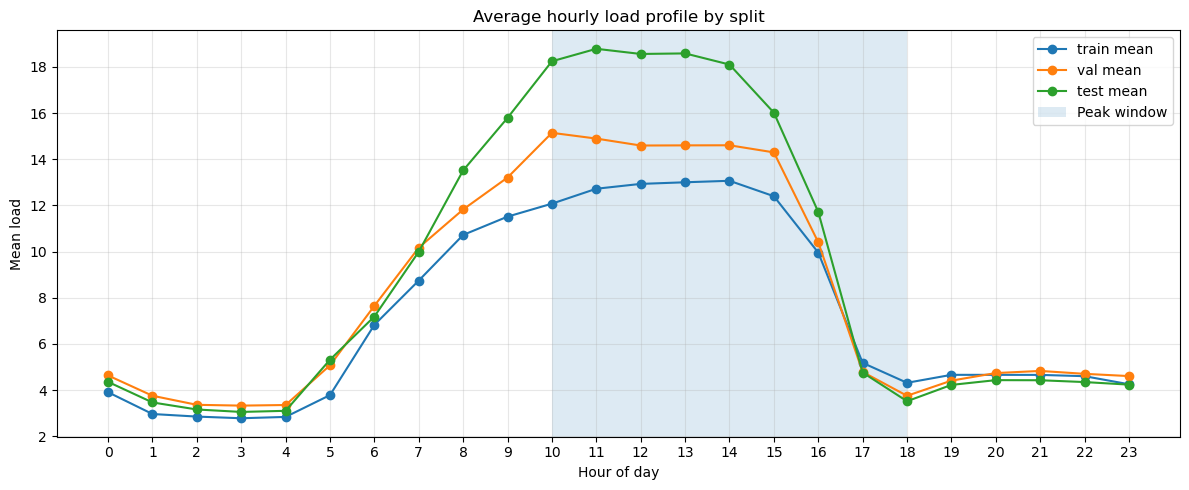

In [50]:
plt.figure(figsize=(12, 5))

for split_name in ["train", "val", "test"]:
    d = hourly_profile[hourly_profile["split"] == split_name]
    plt.plot(d["hour"], d["mean"], marker="o", label=f"{split_name} mean")

plt.axvspan(10, 18, alpha=0.15, label="Peak window")
plt.title("Average hourly load profile by split")
plt.xlabel("Hour of day")
plt.ylabel("Mean load")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
def dayofweek_profile_by_split(train_df, val_df, test_df, target_col):
    rows = []

    for split_name, d in [
        ("train", train_df),
        ("val", val_df),
        ("test", test_df),
    ]:
        temp = d[[target_col]].copy()
        temp["dayofweek"] = temp.index.dayofweek

        prof = temp.groupby("dayofweek")[target_col].agg(["mean", "median", "std", "max"])
        prof["split"] = split_name
        prof = prof.reset_index()

        rows.append(prof)

    return pd.concat(rows, ignore_index=True)

dow_profile = dayofweek_profile_by_split(train_df, val_df, test_df, target_col)
dow_profile

,dayofweek,mean,median,std,max,split
0,0,8.119487,5.684665,5.298885,30.31700,train
1,1,8.393454,5.984670,5.441629,26.92433,train
2,2,8.173824,5.567000,5.387917,26.02333,train
3,3,7.544768,5.218335,4.783955,24.94800,train
4,4,7.796119,5.567835,4.949031,24.66100,train
5,5,5.824559,4.626165,3.351879,22.38333,train
6,6,5.589756,4.569835,3.028549,16.49767,train
7,0,8.600448,5.368165,6.214995,24.93433,val
8,1,9.244986,6.567335,6.024297,24.70667,val
9,2,9.034138,6.394335,5.554230,21.59367,val


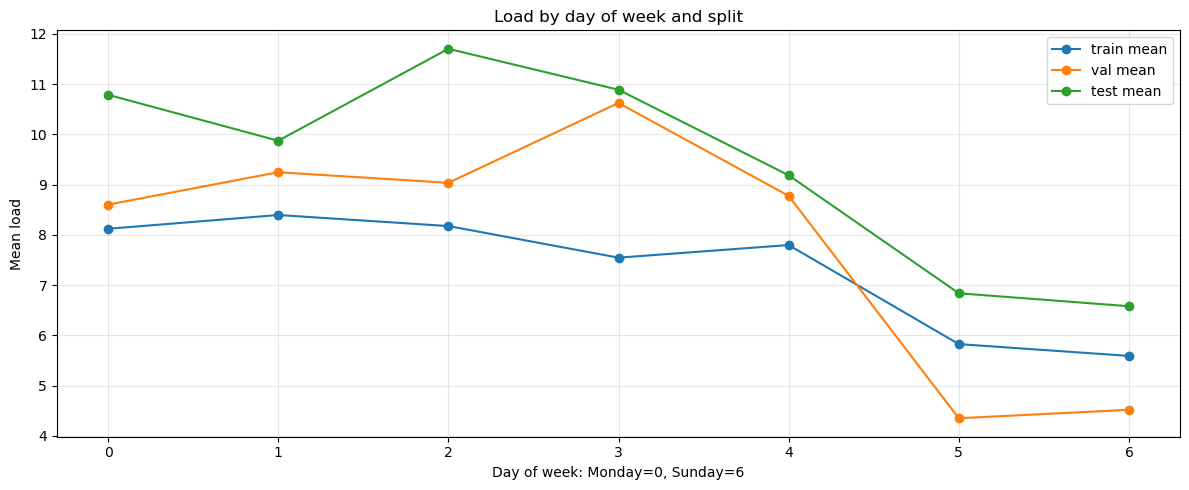

In [52]:
plt.figure(figsize=(12, 5))

for split_name in ["train", "val", "test"]:
    d = dow_profile[dow_profile["split"] == split_name]
    plt.plot(d["dayofweek"], d["mean"], marker="o", label=f"{split_name} mean")

plt.title("Load by day of week and split")
plt.xlabel("Day of week: Monday=0, Sunday=6")
plt.ylabel("Mean load")
plt.xticks(range(7))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
def compare_train_test_shift(train_summary, test_summary):
    train = train_summary.iloc[0]
    test = test_summary.iloc[0]

    metrics = ["mean", "median", "std", "q75", "q90", "q95", "max"]

    rows = []
    for m in metrics:
        train_val = train[m]
        test_val = test[m]

        pct_change = ((test_val - train_val) / train_val * 100) if train_val != 0 else np.nan

        rows.append({
            "metric": m,
            "train": train_val,
            "test": test_val,
            "difference": test_val - train_val,
            "pct_change_%": pct_change,
        })

    return pd.DataFrame(rows)

# Full day shift
full_shift = compare_train_test_shift(
    split_summary[split_summary["split"] == "train"],
    split_summary[split_summary["split"] == "test"],
)

# Peak window shift
peak_shift = compare_train_test_shift(
    peak_split_summary[peak_split_summary["split"] == "train"],
    peak_split_summary[peak_split_summary["split"] == "test"],
)

print("Full-day shift:")
display(full_shift)

print("Peak-window shift:")
display(peak_shift)

Full-day shift:


,metric,train,test,difference,pct_change_%
0,mean,7.315349,9.087651,1.772302,24.227167
1,median,5.118835,5.058000,-0.060835,-1.188454
2,std,4.795385,7.320209,2.524824,52.651133
3,q75,10.575753,12.986500,2.410747,22.795045
4,q90,14.576270,21.353066,6.776796,46.491976
5,q95,17.085034,24.814500,7.729466,45.241155
6,max,30.317000,37.119330,6.802330,22.437345


Peak-window shift:


,metric,train,test,difference,pct_change_%
0,mean,11.415096,15.594074,4.178979,36.609233
1,median,11.357000,14.405665,3.048665,26.843929
2,std,4.695556,7.634420,2.938863,62.588179
3,q75,14.663000,21.219582,6.556582,44.715150
4,q90,17.647836,26.475068,8.827232,50.018779
5,q95,19.412697,28.324120,8.911423,45.905126
6,max,30.317000,37.119330,6.802330,22.437345


In [54]:
def high_peak_day_count(daily_peak_summary, train_df, val_df, test_df, threshold=None):
    if threshold is None:
        threshold = daily_peak_summary["peakwin_max"].quantile(0.80)

    rows = []

    for split_name, d in [
        ("train", train_df),
        ("val", val_df),
        ("test", test_df),
    ]:
        start = d.index.min().normalize()
        end = d.index.max().normalize()

        sub = daily_peak_summary[
            (daily_peak_summary.index >= start) &
            (daily_peak_summary.index <= end)
        ]

        rows.append({
            "split": split_name,
            "n_days": len(sub),
            "threshold": threshold,
            "high_peak_days": int((sub["peakwin_max"] >= threshold).sum()),
            "high_peak_day_ratio_%": (sub["peakwin_max"] >= threshold).mean() * 100 if len(sub) else np.nan,
            "mean_peakwin_max": sub["peakwin_max"].mean(),
            "max_peakwin_max": sub["peakwin_max"].max(),
        })

    return pd.DataFrame(rows)

high_peak_counts = high_peak_day_count(
    daily_peak_summary,
    train_df,
    val_df,
    test_df,
)

high_peak_counts

,split,n_days,threshold,high_peak_days,high_peak_day_ratio_%,mean_peakwin_max,max_peakwin_max
0,train,80,22.244334,10,12.500000,16.782183,30.31700
1,val,18,22.244334,4,22.222222,19.837796,51.22767
2,test,18,22.244334,10,55.555556,23.585685,37.11933


In [55]:
train_peak = train_df[(train_df.index.hour >= 10) & (train_df.index.hour < 18)]
val_peak = val_df[(val_df.index.hour >= 10) & (val_df.index.hour < 18)]
test_peak = test_df[(test_df.index.hour >= 10) & (test_df.index.hour < 18)]

peak_split_summary = load_distribution_summary(
    train_peak,
    val_peak,
    test_peak,
    target_col
)

peak_split_summary

,split,start,end,n_samples,mean,median,std,min,q10,q25,q75,q90,q95,max
0,train,2025-10-18 10:00:00,2026-01-05 17:45:00,2560,11.415096,11.357000,4.695556,2.49467,5.007770,7.783170,14.663000,17.647836,19.412697,30.31700
1,val,2026-01-06 10:00:00,2026-01-22 17:45:00,544,12.913946,13.831335,6.546916,2.62500,4.524531,6.175998,17.580415,20.341030,22.386719,51.22767
2,test,2026-01-23 10:00:00,2026-02-08 17:45:00,544,15.594074,14.405665,7.634420,3.38500,5.300631,9.409917,21.219582,26.475068,28.324120,37.11933


In [13]:
df_imputed.columns.tolist()

['BU_TotActPwr_Academy',
 'BA_Soc',
 'PV_WS_AirTemp',
 'PV_WS_Radiation',
 'dayofweek',
 'is_weekend',
 'hour',
 'sin_tod',
 'cos_tod',
 'sin_dow',
 'cos_dow',
 'is_midday_peak_window',
 'is_midday_weekday_peak',
 'BU_TotActPwr_Academy_lag_4',
 'BU_TotActPwr_Academy_lag_8',
 'BU_TotActPwr_Academy_lag_12',
 'BU_TotActPwr_Academy_lag_24',
 'BU_TotActPwr_Academy_lag_48',
 'BU_TotActPwr_Academy_lag_96',
 'BU_TotActPwr_Academy_lag_192',
 'BU_TotActPwr_Academy_lag_288',
 'BU_TotActPwr_Academy_roll_mean_24',
 'BU_TotActPwr_Academy_roll_mean_48',
 'BU_TotActPwr_Academy_roll_mean_96',
 'BU_TotActPwr_Academy_roll_mean_288',
 'BU_TotActPwr_Academy_roll_std_12',
 'BU_TotActPwr_Academy_roll_std_24',
 'BU_TotActPwr_Academy_roll_std_48',
 'BU_TotActPwr_Academy_roll_std_96',
 'BU_TotActPwr_Academy_trend_4_8',
 'BU_TotActPwr_Academy_trend_4_12',
 'BU_TotActPwr_Academy_trend_4_96',
 'BU_TotActPwr_Academy_trend_96_192',
 'BU_TotActPwr_Academy_yesterday_mean',
 'BU_TotActPwr_Academy_yesterday_max',
 'BU_T

## without resedulas

In [14]:
target_col = "BU_TotActPwr_Academy"
feature_cols = [c for c in df_imputed.columns if c != target_col]

results_df, horizon_results = run_profile_training_experiment(
    df=df_imputed,
    target_col=target_col,
    feature_cols=feature_cols,
    dataset_name="15min_Imputed",
    feature_set_name="ALL_features",
    horizon_steps=672,
    issue_hour=23,
    issue_minute=45,
    train_ratio=0.80,
    val_ratio=0.10,
    test_ratio=0.10,
    selected_models=["ridge", "random_forest", "xgboost"],
    drop_feature_nan=False,
    data_mode="dense",
)

results_df

Training ridge for day-ahead profile forecasting: BU_TotActPwr_Academy [dense]
Training random_forest for day-ahead profile forecasting: BU_TotActPwr_Academy [dense]
Training xgboost for day-ahead profile forecasting: BU_TotActPwr_Academy [dense]


,run_id,timestamp,task_type,dataset_name,feature_set_name,data_mode,target,model_name,model_params,n_features,...,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_R2,model_path,prediction_path,horizon_metrics_path,plot_path,params_path
0,run_20260428_134212_a7f786f3,2026-04-28 13:42:12,day_ahead_profile_forecasting,15min_Imputed,ALL_features,dense,BU_TotActPwr_Academy,ridge,"{""estimator__alpha"": 5.0, ""estimator__copy_X"":...",37,...,2.617036,4.384221,22.645725,24.354639,0.683696,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...
1,run_20260428_134215_71e387d9,2026-04-28 13:42:15,day_ahead_profile_forecasting,15min_Imputed,ALL_features,dense,BU_TotActPwr_Academy,random_forest,"{""estimator__bootstrap"": true, ""estimator__ccp...",37,...,2.513718,4.276895,20.274814,21.740758,0.698993,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...
2,run_20260428_135301_aea58081,2026-04-28 13:53:01,day_ahead_profile_forecasting,15min_Imputed,ALL_features,dense,BU_TotActPwr_Academy,xgboost,"{""estimator__objective"": ""reg:squarederror"", ""...",37,...,2.541928,4.293931,21.046769,22.533555,0.696590,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...


# Data_Nans

    "BU_TotActPwr_Academy",
    "BA_TotActPwr_BESS_AC_Panel1",
    "BA_TotActPwr_BESS_AC_Panel2",
    "BU_TotActPwr_Tech_Room",
    "BU_TotActPwr_SDB_EL_Substation",

In [105]:
path = r"C:\Data_analysis\Thesis\Data\03_Training\Data_with_NaNs\15_min\df_BU_TotActPwr_Tech_Room.parquet"
df_with_nans = pd.read_parquet(path)

In [106]:
df_with_nans.head()

,BU_TotActPwr_Tech_Room,BA_Soc,PV_WS_AirTemp,PV_WS_Radiation,dayofweek,is_weekend,hour,month,dayofmonth,minute_of_day,...,BU_TotActPwr_Tech_Room_roll_std_96,BU_TotActPwr_Tech_Room_trend_1_4,BU_TotActPwr_Tech_Room_trend_1_12,BU_TotActPwr_Tech_Room_trend_1_96,BU_TotActPwr_Tech_Room_trend_96_192,BU_TotActPwr_Tech_Room_yesterday_mean,BU_TotActPwr_Tech_Room_yesterday_max,BU_TotActPwr_Tech_Room_yesterday_midday_max,BU_TotActPwr_Tech_Room_yesterday_peak_time_step,BU_TotActPwr_Tech_Room_lastweek_same_day_peak
Time,,,,,,,,,,,,,,,,,,,,,
2025-10-15 00:00:00,3.62267,83.36667,128.33333,-4.53333,2,0,0,10,15,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-15 00:15:00,3.62067,83.10000,127.00000,-4.36667,2,0,0,10,15,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-15 00:30:00,3.68567,82.80000,126.33333,-4.43333,2,0,0,10,15,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-15 00:45:00,3.68367,82.56667,125.00000,-4.70000,2,0,0,10,15,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-15 01:00:00,3.59833,82.26667,123.33333,-4.50000,2,0,1,10,15,60,...,NaN,0.061,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [107]:
target_col = "BU_TotActPwr_Tech_Room"
results_df_nan, horizon_results_nan = run_profile_training_experiment(
    df=df_with_nans,
    target_col=target_col,
    feature_cols=[c for c in df_with_nans.columns if c != target_col],
    dataset_name="15min_nans",
    feature_set_name="weather_features",
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    train_ratio=0.80,
    val_ratio=0.10,
    test_ratio=0.10,
    selected_models=["hist_gbr", "xgboost"],
    drop_feature_nan=False,
    data_mode="NaNs",
)

results_df_nan

Training hist_gbr for day-ahead profile forecasting: BU_TotActPwr_Tech_Room [NaNs]
Training xgboost for day-ahead profile forecasting: BU_TotActPwr_Tech_Room [NaNs]


,run_id,timestamp,task_type,dataset_name,feature_set_name,data_mode,target,model_name,model_params,n_features,...,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_R2,model_path,prediction_path,horizon_metrics_path,plot_path,params_path
0,run_20260410_172038_4b7b1df9,2026-04-10 17:20:38,day_ahead_profile_forecasting,15min_nans,weather_features,NaNs,BU_TotActPwr_Tech_Room,hist_gbr,"{""estimator__categorical_features"": ""from_dtyp...",48,...,0.318112,0.459920,21.613918,21.217906,0.897199,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...
1,run_20260410_172143_3c35a617,2026-04-10 17:21:43,day_ahead_profile_forecasting,15min_nans,weather_features,NaNs,BU_TotActPwr_Tech_Room,xgboost,"{""estimator__objective"": ""reg:squarederror"", ""...",48,...,0.203547,0.363876,12.610058,12.871555,0.935652,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...


# Plots

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_profile_day(prediction_csv_path, row_idx=0, title=None):
    df = pd.read_csv(prediction_csv_path, index_col=0, parse_dates=True)

    true_cols = [c for c in df.columns if c.endswith("_true")]
    pred_cols = [c for c in df.columns if c.endswith("_pred")]

    true_vals = df.iloc[row_idx][true_cols].values.astype(float)
    pred_vals = df.iloc[row_idx][pred_cols].values.astype(float)

    issue_time = df.index[row_idx]

    plt.figure(figsize=(14, 5))
    plt.plot(true_vals, label="Actual")
    plt.plot(pred_vals, label="Predicted")
    plt.xlabel("15-minute step of next day")
    plt.ylabel("Load / Power")
    plt.title(title or f"Day-ahead profile forecast\nIssue time: {issue_time}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
prediction_csv_path = r"C:\Data_analysis\Thesis\JupyterNotebooks\artifacts\profile_forecasting\predictions\multi_xgboost_BU_TotActPwr_Tech_Room_profile_predictions.csv"
plot_profile_day(prediction_csv_path, row_idx=0)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_multiple_profile_days(prediction_csv_path, row_indices=(0, 1, 2)):
    df = pd.read_csv(prediction_csv_path, index_col=0, parse_dates=True)

    true_cols = [c for c in df.columns if c.endswith("_true")]
    pred_cols = [c for c in df.columns if c.endswith("_pred")]

    for row_idx in row_indices:
        true_vals = df.iloc[row_idx][true_cols].values.astype(float)
        pred_vals = df.iloc[row_idx][pred_cols].values.astype(float)
        issue_time = df.index[row_idx]

        plt.figure(figsize=(14, 5))
        plt.plot(true_vals, label="Actual")
        plt.plot(pred_vals, label="Predicted")
        plt.xlabel("15-minute step of next day")
        plt.ylabel("Load / Power")
        plt.title(f"Day-ahead profile forecast\nIssue time: {issue_time}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [ ]:
plot_multiple_profile_days(
    prediction_csv_path,
    row_indices=(0, 5, 10)
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_average_profile(prediction_csv_path, title="Average day-ahead profile"):
    df = pd.read_csv(prediction_csv_path, index_col=0, parse_dates=True)

    true_cols = [c for c in df.columns if c.endswith("_true")]
    pred_cols = [c for c in df.columns if c.endswith("_pred")]

    true_mean = df[true_cols].mean(axis=0).values.astype(float)
    pred_mean = df[pred_cols].mean(axis=0).values.astype(float)

    plt.figure(figsize=(14, 5))
    plt.plot(true_mean, label="Average Actual")
    plt.plot(pred_mean, label="Average Predicted")
    plt.xlabel("15-minute step of next day")
    plt.ylabel("Load / Power")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_average_profile(prediction_csv_path)

In [ ]:
import pandas as pd
import numpy as np


def load_profile_predictions_as_timeseries(prediction_csv_path: str) -> pd.DataFrame:

    df = pd.read_csv(prediction_csv_path, index_col=0, parse_dates=True)

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = sorted([c for c in df.columns if c.endswith("_pred")])

    if len(true_cols) != len(pred_cols):
        raise ValueError("Mismatch between number of true and predicted columns.")

    records = []

    for issue_time, row in df.iterrows():
        for i, (t_col, p_col) in enumerate(zip(true_cols, pred_cols), start=1):
            forecast_time = issue_time + pd.Timedelta(minutes=15 * i)

            actual = float(row[t_col])
            predicted = float(row[p_col])

            records.append({
                "forecast_time": forecast_time,
                "issue_time": issue_time,
                "step": i,
                "actual": actual,
                "predicted": predicted,
                "residual": actual - predicted,
                "abs_error": abs(actual - predicted),
            })

    ts_df = pd.DataFrame(records).sort_values("forecast_time")
    ts_df = ts_df.set_index("forecast_time")

    return ts_df

In [ ]:
import matplotlib.pyplot as plt


def plot_profile_diagnostics(
    prediction_csv_path: str,
    model_name: str = "profile_model",
    target_name: str = "target",
    dataset_name: str = "dataset",
    zoom_start: str | None = None,
    zoom_end: str | None = None,
    figsize=(16, 16),
):
    """
    Create a 4-panel diagnostic plot similar to your screenshot:
    1. Actual vs Predicted over time
    2. Residuals over time
    3. Zoomed window
    4. Actual vs Predicted scatter
    """
    ts_df = load_profile_predictions_as_timeseries(prediction_csv_path)

    if zoom_start is None:
        zoom_start = str(ts_df.index.min())
    if zoom_end is None:
        zoom_end = str(min(ts_df.index.min() + pd.Timedelta(days=3), ts_df.index.max()))

    zoom_df = ts_df.loc[zoom_start:zoom_end].copy()

    fig, axes = plt.subplots(4, 1, figsize=figsize)

    title_prefix = f"{model_name} - {target_name} [{dataset_name}]"

    # 1. Actual vs predicted over time
    axes[0].plot(ts_df.index, ts_df["actual"], label="Actual")
    axes[0].plot(ts_df.index, ts_df["predicted"], label="Predicted")
    axes[0].set_title(title_prefix)
    axes[0].set_ylabel(f"{target_name} [kW]")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2. Residuals over time
    axes[1].plot(ts_df.index, ts_df["residual"])
    axes[1].axhline(0, linestyle="--")
    axes[1].set_title(f"{title_prefix} - Residuals Over Time")
    axes[1].set_ylabel("Residual [kW]")
    axes[1].grid(True, alpha=0.3)

    # 3. Zoomed window
    axes[2].plot(zoom_df.index, zoom_df["actual"], label="Actual")
    axes[2].plot(zoom_df.index, zoom_df["predicted"], label="Predicted")
    axes[2].set_title(f"{title_prefix} - Zoomed Window")
    axes[2].set_ylabel(f"{target_name} [kW]")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    # 4. Scatter
    axes[3].scatter(ts_df["actual"], ts_df["predicted"], alpha=0.5)
    min_val = min(ts_df["actual"].min(), ts_df["predicted"].min())
    max_val = max(ts_df["actual"].max(), ts_df["predicted"].max())
    axes[3].plot([min_val, max_val], [min_val, max_val], linestyle="--")
    axes[3].set_title(f"{title_prefix} - Actual vs Predicted Scatter")
    axes[3].set_xlabel("Actual [kW]")
    axes[3].set_ylabel("Predicted [kW]")
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
prediction_csv_path = r"C:\Data_analysis\Thesis\JupyterNotebooks\artifacts\profile_forecasting\predictions\multi_xgboost_BU_TotActPwr_Tech_Room_profile_predictions.csv"

plot_profile_diagnostics(
    prediction_csv_path=prediction_csv_path,
    model_name="multi_xgboost",
    target_name="BU_TotActPwr_Tech_Room",
    dataset_name="15min_profile_data",
    zoom_start="2026-01-29",
    zoom_end="2026-02-02",
)

In [ ]:

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch version:", torch.__version__)
print("Device:", device)
